<a href="https://colab.research.google.com/github/git-oreoluwa/Data-Science-BootCamp-Projects-Phase-II/blob/main/02_Exploratory_Data_Analysis/%20Uber_Travel_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Uber**
Uber is a global ride-hailing service founded in 2009, revolutionizing urban transportation by allowing users to book rides via a mobile app. It connects passengers with drivers of vehicles for hire, offering a convenient, on-demand service. Uber operates in hundreds of cities worldwide, providing various services, including UberX (standard rides), UberPOOL (shared rides), and UberBLACK (luxury rides). In addition to ride-hailing, Uber has expanded into food delivery (Uber Eats) and freight logistics (Uber Freight). Known for its user-friendly app and cashless transactions, Uber has transformed how people move within cities.

## **Uber Travel Analysis**
The Uber Travel Analysis Project aims to explore and understand user travel patterns through Uber's services. Leveraging a comprehensive dashboard, this project analyzes various aspects of Uber trips, including trip categories, peak travel hours, trip purposes, distances covered, and the busiest days and months. The analysis also investigates the most popular starting locations for Uber rides, providing a clear picture of where demand is highest.

By visualizing these data points, the project offers insights into user behavior, such as when people are most likely to take Uber, the motivations behind their trips, and the typical distances they travel. These insights can help Uber optimize its operations, ensuring better resource allocation during peak periods and improving service quality in high-demand areas. Ultimately, this project provides a data-driven perspective on Uber travel trends, supporting decision-making for both service providers and stakeholders.

### **Objectives**
 1. Check how long people travel with uber ?
 2. What hour do most people take uber to their destination?
 3. Check the purpose of the trips?
 4. Which Day has the highest number of tirps?
 5. What are the trips in the month?
 6. The starting point of trips. Where do people start bording their trip from the most?

In [17]:
#import libs
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import calendar

In [18]:
# import data
data = pd.read_csv("Uber_Drives.csv")

**Data Exploration**

In [19]:
# Check the heads

data.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01/01/2016 21:11,01/01/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016 01:25,01/02/2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01/02/2016 20:25,01/02/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016 17:31,01/05/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016 14:42,01/06/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [20]:
# Checking the dimensionality of the data
data.shape

(1156, 7)

In [21]:
# Checking the data types or info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


**Observation**
- The start date and end state are saved as object, and it should be saved as datetime during data cleaning
- Category should be daved as Category during data cleaning and Purpose should also be examined.

In [22]:
data.columns

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')

**Data Cleaning**

In [23]:
data.isnull().sum() #cheking the missing values

,0
START_DATE*,0
END_DATE*,1
CATEGORY*,1
START*,1
STOP*,1
MILES*,0
PURPOSE*,503


In [24]:
data = data.drop([1155],axis=0)

data.tail()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [25]:
data.isnull().sum() #cheking the missing values

,0
START_DATE*,0
END_DATE*,0
CATEGORY*,0
START*,0
STOP*,0
MILES*,0
PURPOSE*,502


In [26]:
# Formatting Datetime
data['START_DATE*'] = pd.to_datetime(data['START_DATE*'], format = '%m/%d/%Y %H:%M')

data['END_DATE*'] = pd.to_datetime(data['END_DATE*'], format = '%m/%d/%Y %H:%M')


In [27]:
# Checking data types
data.dtypes

,0
START_DATE*,datetime64[ns]
END_DATE*,datetime64[ns]
CATEGORY*,object
START*,object
STOP*,object
MILES*,float64
PURPOSE*,object


In [28]:
# converting objects dtypes to category

data['CATEGORY*'] = data['CATEGORY*'].astype('category')
data['PURPOSE*'] = data['PURPOSE*'].astype('category')

data.dtypes


,0
START_DATE*,datetime64[ns]
END_DATE*,datetime64[ns]
CATEGORY*,category
START*,object
STOP*,object
MILES*,float64
PURPOSE*,category


In [31]:
# Extracting the hours, day and month from start date

data['HOUR'] = data['START_DATE*'].dt.hour
data['DAY'] = data['START_DATE*'].dt.day
data['MONTH'] = data['START_DATE*'].dt.month_name()
data['DAY_WEEK'] = data['START_DATE*'].dt.dayofweek
data['WEEK_DAY'] = data['START_DATE*'].dt.day_name()

data.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,HOUR,DAY,MONTH,DAY_WEEK,WEEK_DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,1,January,4,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,1,2,January,5,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20,2,January,5,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17,5,January,1,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14,6,January,2,Wednesday


In [32]:
# repositioning columns

data.insert(1,'HOUR', data.pop('HOUR'))
data.insert(2,'DAY', data.pop('DAY'))
data.insert(3,'MONTH', data.pop('MONTH'))
data.insert(4,'DAY_WEEK', data.pop('DAY_WEEK'))
data.insert(5,'WEEK_DAY', data.pop('WEEK_DAY'))

data.head()

,START_DATE*,HOUR,DAY,MONTH,DAY_WEEK,WEEK_DAY,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,2016-01-01 21:11:00,21,1,January,4,Friday,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,1,2,January,5,Saturday,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,2016-01-02 20:25:00,20,2,January,5,Saturday,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,17,5,January,1,Tuesday,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,14,6,January,2,Wednesday,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [15]:
#Creating more columns for analysis

"""
hour = []
day = []
month = []
dayofweek = []
weekday = []

#Extracting day and time using for loop
for k in data['START_DATE*']:
    hour.append(k.hour)
    day.append(k.day)
    month.append(calendar.month_name[k.month])
    dayofweek.append(k.dayofweek)
    weekday.append(calendar.day_name[dayofweek[-1]])

#creating columns

data['HOUR'] = hour
data['DAY'] = day
data['MONTH'] = month
data['DAY_WEEK'] = dayofweek
data['WEEK_DAY'] = weekday

"""

**1. Check how long people travel with uber ?**

In [34]:
data['MILES*'].value_counts().head()

,count
MILES*,
9.9,28
3.1,26
10.4,19
3.0,19
2.1,19


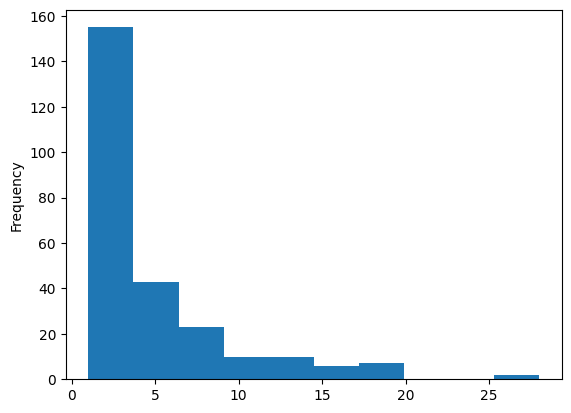

In [35]:
#Visualization
data['MILES*'].value_counts().plot(kind='hist')

plt.show()

**2. What hour do most people take uber to their destination?**

In [36]:
data['HOUR'].value_counts().head(6)

,count
HOUR,
15,98
17,95
13,94
18,94
14,89
16,88


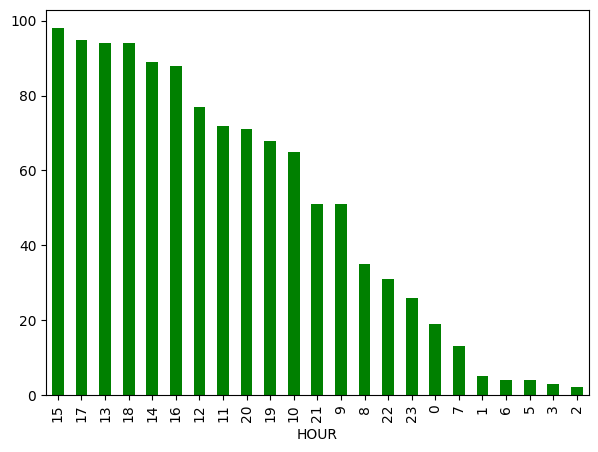

In [37]:
#Visualization
plt.figure(figsize = (7,5))
data['HOUR'].value_counts().plot(kind = 'bar', color = 'green')

plt.show()

**3. Check the purpose of the trips?**

In [38]:
data['PURPOSE*'].value_counts()


,count
PURPOSE*,
Meeting,187
Meal/Entertain,160
Errand/Supplies,128
Customer Visit,101
Temporary Site,50
Between Offices,18
Moving,4
Airport/Travel,3
Charity ($),1


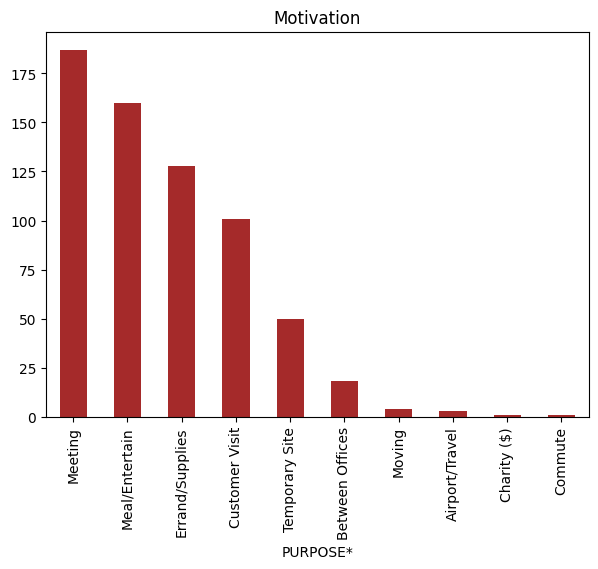

In [41]:
#Visualization
data['PURPOSE*'].value_counts().plot(kind = 'bar', color = 'brown', figsize = (7,5))
plt.title('Motivation')
plt.show()

**4. Which Day has the highest number of tirps?**

In [42]:
data['WEEK_DAY'].value_counts()

,count
WEEK_DAY,
Friday,206
Tuesday,176
Monday,174
Thursday,154
Saturday,150
Sunday,148
Wednesday,147


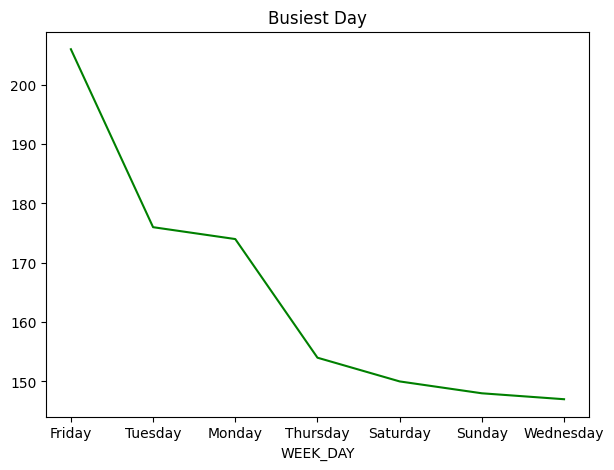

In [43]:
#Visualization
data['WEEK_DAY'].value_counts().plot(kind='line', color = 'green',figsize = (7,5))
plt.title('Busiest Day')

plt.show()

**5. What are the trips in the month?**

In [44]:
data['MONTH'].value_counts()

,count
MONTH,
December,146
August,133
November,122
February,115
March,113
July,112
June,108
October,106
January,61


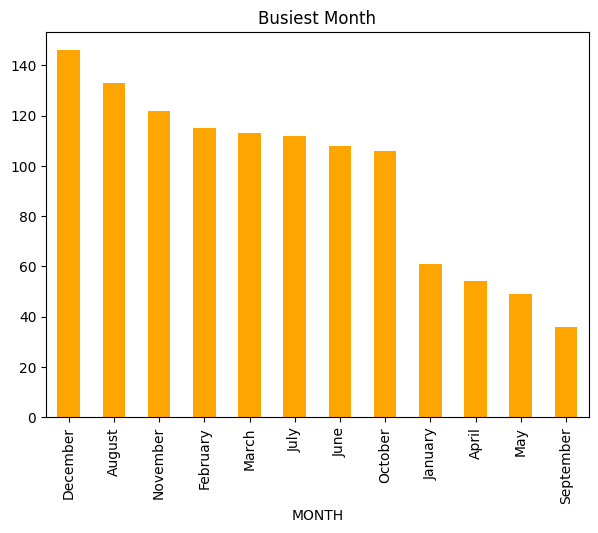

In [45]:
#Visualization
data['MONTH'].value_counts().plot(kind='bar', color = 'orange',figsize = (7,5))
plt.title('Busiest Month')

plt.show()

**6. The starting point of trips. Where do people start bording their trip from the most?**

In [47]:
data['START*'].value_counts().head(8)

,count
START*,
Cary,201
Unknown Location,148
Morrisville,85
Whitebridge,68
Islamabad,57
Durham,37
Lahore,36
Raleigh,28


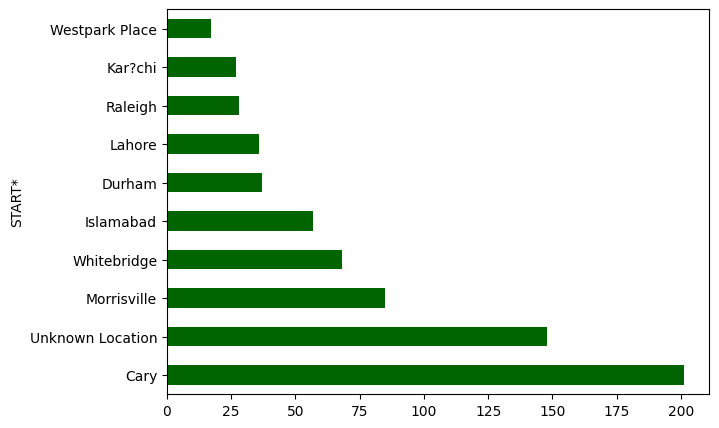

In [48]:
#Visualization
data['START*'].value_counts().head(10).plot(kind = 'barh', color = '#006400',figsize = (7,5) )
plt.show()